# 01 - Exploratory Data Analysis

**Dataset:** UCI Air Quality - one year of hourly readings from a field-deployed multisensor gas device in an Italian city (5 metal-oxide sensors + temperature / humidity probes).

**Forecasting target:** next-hour benzene concentration `C6H6(GT)` (micro-g/m^3). Benzene is the cleanest reference-analyzer channel (only ~3.9% missing) and is a regulated urban air-quality pollutant, so predicting its short-term trend is a realistic monitoring task.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
from IPython.display import Image, display
from src import config as C, data_cleaning as dc, plots as P
raw = dc.load_raw()
print('raw shape:', raw.shape)
raw.head()

raw shape: (9357, 13)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


### Missing readings per channel
The device writes the sentinel `-200` whenever a reading is missing. Sensor channels drop out together (~3.9%); the lab reference channels `CO(GT)/NOx(GT)/NO2(GT)` are ~18% missing and `NMHC(GT)` is ~90% missing (dropped).

,% missing
PT08.S1(CO),3.9
C6H6(GT),3.9
PT08.S3(NOx),3.9
PT08.S2(NMHC),3.9
RH,3.9
T,3.9
PT08.S5(O3),3.9
PT08.S4(NO2),3.9
AH,3.9
NOx(GT),17.5


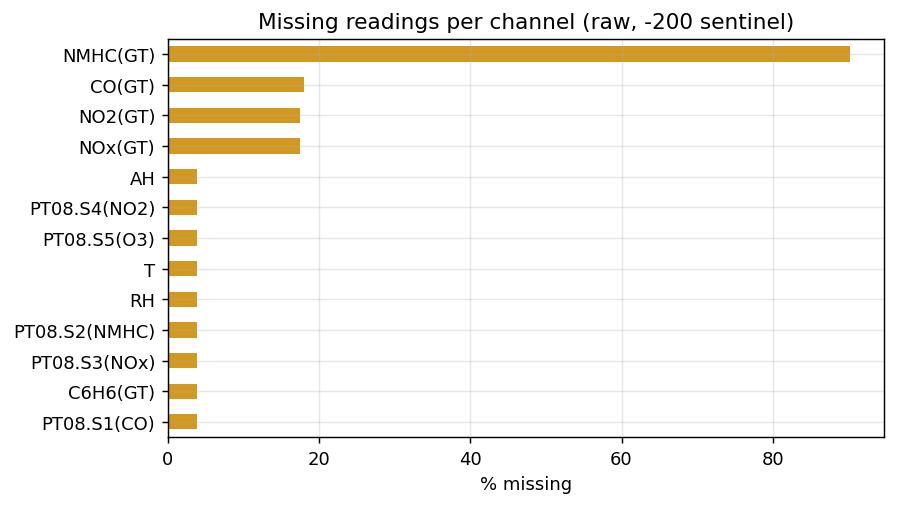

In [2]:
raw_na = (raw.replace(C.MISSING_SENTINEL, np.nan).isna().mean()*100).round(1)
display(raw_na.sort_values().to_frame('% missing'))
P.plot_missingness(raw_na); display(Image('../reports/figures/02_missingness.png'))

### Target series and channel correlations

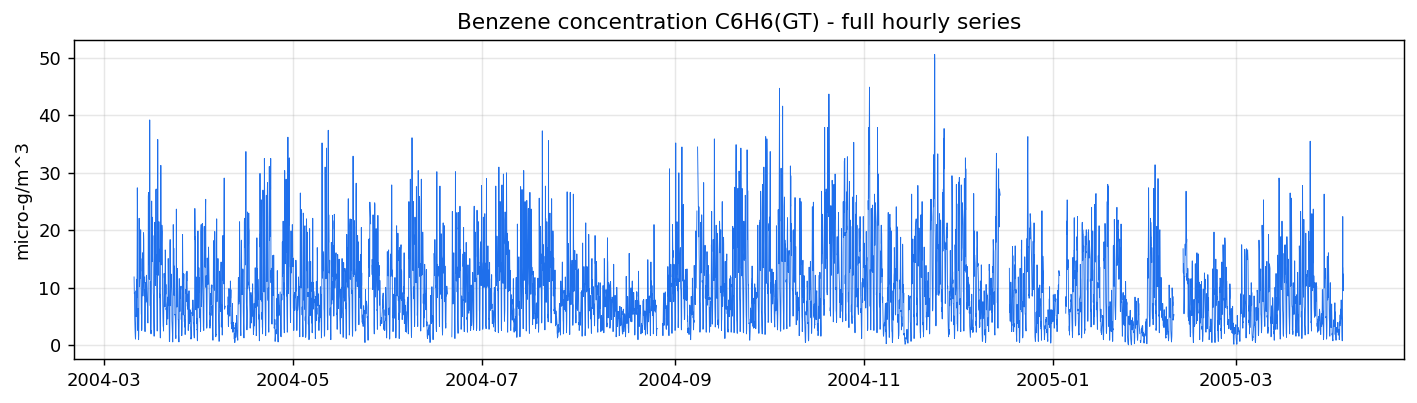

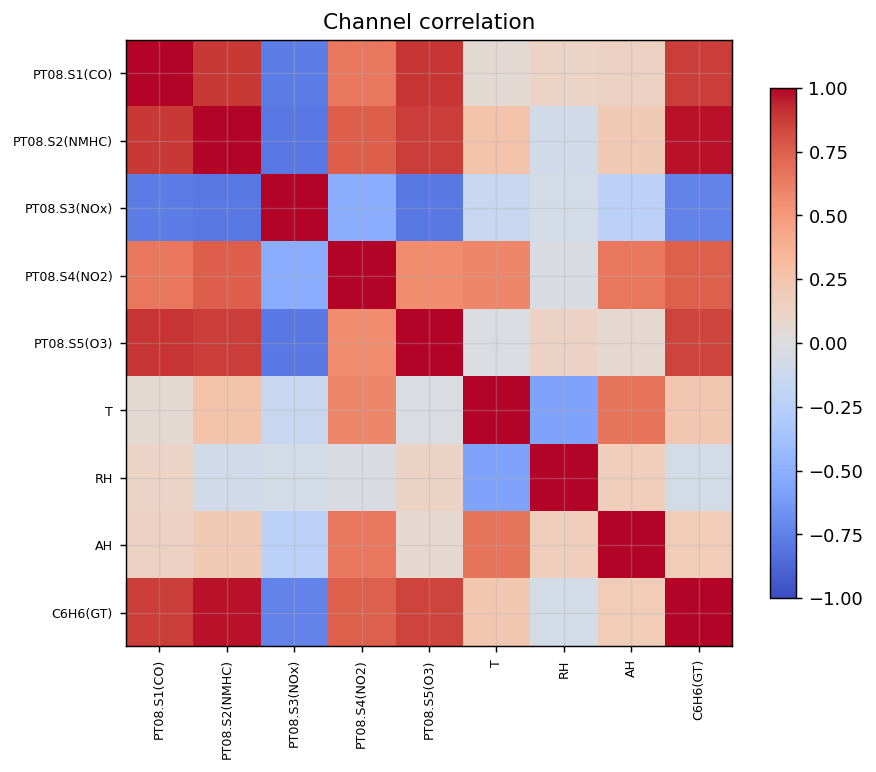

In [3]:
cleaned = dc.clean(raw)
P.plot_target_series(cleaned); display(Image('../reports/figures/01_target_series.png'))
P.plot_correlation(cleaned); display(Image('../reports/figures/03_correlation.png'))

**Takeaways:** strong daily seasonality and rush-hour peaks in benzene; the `PT08.S2` tin-oxide sensor is very highly correlated with benzene ground truth, so the cheap sensors carry real predictive signal.